# Multivariate Statistical Analysis — Term Project (Summer 2026)
Reproducible analysis script. Run all cells top to bottom.

# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.multivariate.manova import MANOVA
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.optimize import minimize

df = pd.read_csv("final_dataset_with_gini.csv")

# Cast text columns to plain object dtype up front. Newer pandas can assign
# the new StringDtype to text columns, which patsy/statsmodels' formula
# parser (used by MANOVA.from_formula) does not recognize -- doing this once
# here avoids a TypeError buried inside Part B.
for col in ["Country", "Region", "DevGroup"]:
    df[col] = df[col].astype(str).astype(object)

health_vars = ["LifeExp", "InfMort", "Sanit", "PhysRate"]
grouping_cols = ["iso3", "Country", "Region", "DevGroup"]

print(f"Loaded {len(df)} countries, {df.shape[1]} columns.")
df.head()

Loaded 179 countries, 22 columns.


,iso3,Country,GDP_pc,Gini,Unemp,Trade,LifeExp,InfMort,Sanit,PhysRate,...,TertEnrl,EdSpend,GenderIdx,Corrupt,UrbanPop,InternetUse,HappyScore,HDI,Region,DevGroup
0,AFG,Afghanistan,1964.452289,NaN,13.351,83.763025,66.289,48.3,54.495799,0.317,...,NaN,NaN,0.661,16.0,25.940164,16.094999,1.446,0.496,AP,Low
1,ALB,Albania,22724.293819,29.4,10.926,79.532815,79.776,8.3,99.299715,NaN,...,84.149620,3.091530,0.107,39.0,58.871474,85.863899,5.662,0.810,EU,Very High
2,DZA,Algeria,15882.713884,27.6,11.633,38.978944,76.475,19.5,85.906486,1.660,...,54.428341,8.977720,0.443,34.0,75.818736,77.417801,5.714,0.763,AF,High
3,AGO,Angola,8760.190820,51.3,14.108,34.646640,64.805,32.1,50.295136,0.244,...,9.954907,2.512737,0.515,32.0,71.461592,40.704800,3.795,0.616,AF,Medium
4,ARG,Argentina,27846.598460,42.4,7.145,30.364634,77.543,8.0,NaN,5.106,...,107.822574,5.003240,0.264,36.0,92.351922,89.667152,6.430,0.865,AM,Very High


In [2]:
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})

In [3]:
# Missingness by variable. This dataset is intentionally NOT globally
# imputed: DevGroup-median imputation would shrink within-group variance
# and partially leak DevGroup information into Region-based group
# comparisons (Parts A & B), which is a real problem for hypothesis tests.
# Instead, each Part below builds its OWN complete-case subset using only
# the variables it actually needs -- this keeps sample size as large as
# each Part's data allows, rather than shrinking every Part down to
# whichever variable is sparsest (LitRate, which we exclude entirely below).
df.isna().sum()

iso3            0
Country         0
GDP_pc          2
Gini           17
Unemp           5
Trade          12
LifeExp         0
InfMort         1
Sanit           5
PhysRate       29
LitRate        95
SchoolYrs       0
TertEnrl       41
EdSpend        17
GenderIdx      11
Corrupt         7
UrbanPop        0
InternetUse     5
HappyScore     23
HDI             0
Region          0
DevGroup        0
dtype: int64

In [4]:
# LitRate is excluded from every analysis: only 84/179 countries have a
# value (53% missing), and including it would cut the Part C/D complete-case
# sample from 88 down to 38 countries -- too aggressive a loss for one
# variable of secondary importance. This is a documented, deliberate
# exclusion, not an oversight; keep the raw column in df for reference.

# Common Functions
Every reusable routine used anywhere in Parts A-E is defined **once** here with descriptive parameter names (never generic globals like `X`/`S`/`H`/`E`). Each Part below only calls these functions on its own local variables, so re-running cells out of order cannot silently corrupt results -- a risk in the original draft where variables like `groups`, `p`, and `X` were reassigned with different meanings across more than a dozen cells.

In [5]:
# --------------------------------------------------------------------------
# 1. MULTIVARIATE NORMALITY: Mardia's test
# --------------------------------------------------------------------------
def mardia_test(X):
    """
    Mardia's multivariate skewness & kurtosis test.
    X : (n, p) array of observations.
    Returns dict with skewness/kurtosis statistics and p-values.
    """
    X = np.asarray(X, dtype=float)
    n, p = X.shape
    Xc = X - X.mean(axis=0)
    S = np.cov(Xc, rowvar=False, bias=True)
    S_inv = np.linalg.inv(S)
    D = Xc @ S_inv @ Xc.T  # Mahalanobis "generalized" product matrix

    b1p = np.sum(D ** 3) / n ** 2
    skew_stat = n * b1p / 6.0
    df_skew = p * (p + 1) * (p + 2) / 6.0
    p_skew = 1.0 - stats.chi2.cdf(skew_stat, df=df_skew)

    b2p = np.trace(D ** 2) / n
    kurt_stat = (b2p - p * (p + 2)) / np.sqrt(8.0 * p * (p + 2) / n)
    p_kurt = 2.0 * (1.0 - stats.norm.cdf(np.abs(kurt_stat)))

    return {
        "n": n, "p": p,
        "skewness_b1p": b1p, "skewness_stat": skew_stat,
        "skewness_df": df_skew, "skewness_pval": p_skew,
        "kurtosis_b2p": b2p, "kurtosis_z": kurt_stat, "kurtosis_pval": p_kurt,
    }


def chi2_qq_plot(X, title="Chi-Square Q-Q Plot for Multivariate Normality"):
    """Chi-square Q-Q plot of squared Mahalanobis distances vs chi2 quantiles."""
    X = np.asarray(X, dtype=float)
    n, p = X.shape
    Xc = X - X.mean(axis=0)
    S_inv = np.linalg.inv(np.cov(X, rowvar=False))
    d2 = np.sum((Xc @ S_inv) * Xc, axis=1)
    d2_sorted = np.sort(d2)
    probs = (np.arange(1, n + 1) - 0.5) / n
    chi2_q = stats.chi2.ppf(probs, df=p)

    plt.figure(figsize=(7, 5))
    plt.scatter(chi2_q, d2_sorted, alpha=0.7, label="Observed $d_i^2$")
    plt.plot([0, chi2_q.max()], [0, chi2_q.max()], "r--", label="Reference line $y=x$")
    plt.title(f"{title} ($p={p}, n={n}$)")
    plt.xlabel(f"Theoretical $\\chi^2_{{{p}}}$ Quantiles")
    plt.ylabel("Ordered Mahalanobis Distances $d_i^2$")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    #plt.savefig("a1_qq_plot.png", dpi=300, bbox_inches="tight")
    plt.show()


# --------------------------------------------------------------------------
# 2. HOMOGENEITY OF COVARIANCE: Box's M test
# --------------------------------------------------------------------------
def box_m_test(X, group_labels):
    """
    Box's M test for equality of covariance matrices across groups.
    X : (n, p) array. group_labels : (n,) array-like of group membership.
    Returns dict with M, chi2 (bias-corrected), df, p-value.
    """
    X = np.asarray(X, dtype=float)
    group_labels = np.asarray(group_labels)
    groups = np.unique(group_labels)
    k, p = len(groups), X.shape[1]

    n_list, S_list = [], []
    for g in groups:
        Xg = X[group_labels == g]
        n_list.append(len(Xg))
        S_list.append(np.cov(Xg, rowvar=False, ddof=1))
    n_arr = np.array(n_list)
    dof_arr = n_arr - 1
    N_minus_k = dof_arr.sum()

    S_pooled = sum(dof_arr[i] * S_list[i] for i in range(k)) / N_minus_k
    M = N_minus_k * np.log(np.linalg.det(S_pooled)) - sum(
        dof_arr[i] * np.log(np.linalg.det(S_list[i])) for i in range(k)
    )
    c = 1.0 - ((2 * p ** 2 + 3 * p - 1) / (6 * (p + 1) * (k - 1))) * (
        np.sum(1.0 / dof_arr) - 1.0 / N_minus_k
    )
    chi2_stat = M * c
    df_box = 0.5 * p * (p + 1) * (k - 1)
    p_val = 1.0 - stats.chi2.cdf(chi2_stat, df=df_box)

    return {"M": M, "c": c, "chi2": chi2_stat, "df": df_box, "pval": p_val}


# --------------------------------------------------------------------------
# 3. HOTELLING'S T^2 TESTS (Part A)
# --------------------------------------------------------------------------
def hotelling_one_sample(X, mu0, alpha=0.05):
    """One-sample Hotelling's T^2 test: H0: mu = mu0."""
    X = np.asarray(X, dtype=float)
    n, p = X.shape
    x_bar = X.mean(axis=0)
    S = np.cov(X, rowvar=False)
    S_inv = np.linalg.inv(S)
    diff = (x_bar - mu0).reshape(-1, 1)

    T2 = float(n * (diff.T @ S_inv @ diff).item())
    F_stat = (n - p) / (p * (n - 1)) * T2
    df1, df2 = p, n - p
    F_crit = stats.f.ppf(1 - alpha, df1, df2)
    p_val = 1 - stats.f.cdf(F_stat, df1, df2)

    # simultaneous (1-alpha) CIs for each component of mu
    multiplier = np.sqrt((p * (n - 1) / (n * (n - p))) * F_crit)
    me = multiplier * np.sqrt(np.diag(S))
    ci_lower, ci_upper = x_bar - me, x_bar + me

    return {"n": n, "p": p, "x_bar": x_bar, "S": S, "T2": T2, "F": F_stat,
            "df1": df1, "df2": df2, "F_crit": F_crit, "pval": p_val,
            "ci_lower": ci_lower, "ci_upper": ci_upper, "margin": me}


def hotelling_two_sample(X1, X2, alpha=0.05, pooled=True):
    """
    Two-sample Hotelling's T^2 test: H0: mu1 = mu2.
    pooled=True  -> classical pooled-covariance T^2 (assumes Sigma1 = Sigma2)
    pooled=False -> Nel-Van der Merwe heteroscedastic approximation
    """
    X1, X2 = np.asarray(X1, float), np.asarray(X2, float)
    n1, p = X1.shape
    n2, _ = X2.shape
    xbar1, xbar2 = X1.mean(axis=0), X2.mean(axis=0)
    S1 = np.cov(X1, rowvar=False, ddof=1)
    S2 = np.cov(X2, rowvar=False, ddof=1)
    diff = (xbar1 - xbar2).reshape(-1, 1)

    if pooled:
        Sp = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n1 + n2 - 2)
        V = Sp * (1.0 / n1 + 1.0 / n2)
        V_inv = np.linalg.inv(V)
        T2 = float((diff.T @ V_inv @ diff).item())
        df1, df2 = p, n1 + n2 - p - 1
        F_stat = df2 / (p * (n1 + n2 - 2)) * T2
        nu = None
    else:
        S1n, S2n = S1 / n1, S2 / n2
        V = S1n + S2n
        V_inv = np.linalg.inv(V)
        T2 = float((diff.T @ V_inv @ diff).item())
        tr_V, tr_V2 = np.trace(V), np.trace(V @ V)
        tr_S1n, tr_S1n2 = np.trace(S1n), np.trace(S1n @ S1n)
        tr_S2n, tr_S2n2 = np.trace(S2n), np.trace(S2n @ S2n)
        nu = (tr_V2 + tr_V ** 2) / (
            (tr_S1n2 + tr_S1n ** 2) / (n1 - 1) + (tr_S2n2 + tr_S2n ** 2) / (n2 - 1)
        )
        df1, df2 = p, nu - p + 1
        F_stat = (nu - p + 1) / (p * nu) * T2

    F_crit = stats.f.ppf(1 - alpha, df1, df2)
    p_val = 1 - stats.f.cdf(F_stat, df1, df2)
    multiplier = np.sqrt((p * (df1 if pooled else nu) / df2) * F_crit) if not pooled \
        else np.sqrt((p * (n1 + n2 - 2) / df2) * F_crit)
    me = multiplier * np.sqrt(np.diag(V))
    diff_flat = diff.flatten()

    return {"n1": n1, "n2": n2, "p": p, "xbar1": xbar1, "xbar2": xbar2,
            "diff": diff_flat, "V": V, "T2": T2, "F": F_stat, "df1": df1,
            "df2": df2, "F_crit": F_crit, "pval": p_val,
            "ci_lower": diff_flat - me, "ci_upper": diff_flat + me, "margin": me,
            "nu": nu}


# --------------------------------------------------------------------------
# 4. ONE-WAY MANOVA (Part B)
# --------------------------------------------------------------------------
def manova_stats(X, group_labels):
    """
    Computes H, E SSCP matrices and all four MANOVA test statistics with
    their standard F-approximations (Wilks via Rao's F, Pillai, Hotelling-
    Lawley via McKeon-style F, Roy's largest root upper-bound F).
    """
    X = np.asarray(X, dtype=float)
    group_labels = np.asarray(group_labels)
    groups = np.unique(group_labels)
    k = len(groups)
    N, p = X.shape
    overall_mean = X.mean(axis=0)

    H = np.zeros((p, p))
    E = np.zeros((p, p))
    for g in groups:
        Xg = X[group_labels == g]
        ng = len(Xg)
        mg = Xg.mean(axis=0)
        d = (mg - overall_mean).reshape(-1, 1)
        H += ng * (d @ d.T)
        c = Xg - mg
        E += c.T @ c

    eigvals = np.sort(np.real(np.linalg.eigvals(np.linalg.inv(E) @ H)))[::-1]
    s = min(p, k - 1)
    m = (abs(p - (k - 1)) - 1) / 2.0
    nn = (N - k - p - 1) / 2.0

    wilks = np.linalg.det(E) / np.linalg.det(E + H)
    pillai = np.trace(H @ np.linalg.inv(E + H))
    hl = np.trace(np.linalg.inv(E) @ H)
    roy = eigvals[0]

    # Rao's F-approximation for Wilks' Lambda
    df_h, df_e = k - 1, N - k
    t = np.sqrt((p ** 2 * df_h ** 2 - 4) / (p ** 2 + df_h ** 2 - 5)) if (p ** 2 + df_h ** 2 - 5) != 0 else 1.0
    df1_w = p * df_h
    df2_w = t * ((N - 1) - (p + df_h) / 2.0) - (p * df_h - 2) / 2.0
    F_wilks = ((1 - wilks ** (1 / t)) / (wilks ** (1 / t))) * (df2_w / df1_w)
    p_wilks = 1 - stats.f.cdf(F_wilks, df1_w, df2_w)

    # Pillai's F-approximation
    df1_p = s * (2 * m + s + 1)
    df2_p = s * (2 * nn + s + 1)
    F_pillai = (pillai / (s - pillai)) * (df2_p / df1_p)
    p_pillai = 1 - stats.f.cdf(F_pillai, df1_p, df2_p)

    # Hotelling-Lawley F-approximation (McKeon)
    df1_hl = s * (2 * m + s + 1)
    df2_hl = 2 * (s * nn + 1)
    F_hl = (hl / s) * (df2_hl / df1_hl)
    p_hl = 1 - stats.f.cdf(F_hl, df1_hl, df2_hl)

    # Roy's largest root (upper bound F, using s = max(p, df_h))
    df1_r = max(p, df_h)
    df2_r = N - k - df1_r + (k - 1)
    F_roy = roy * df2_r / df1_r
    p_roy = 1 - stats.f.cdf(F_roy, df1_r, df2_r)

    return {
        "H": H, "E": E, "eigvals": eigvals,
        "wilks": wilks, "F_wilks": F_wilks, "df1_wilks": df1_w, "df2_wilks": df2_w, "p_wilks": p_wilks,
        "pillai": pillai, "F_pillai": F_pillai, "df1_pillai": df1_p, "df2_pillai": df2_p, "p_pillai": p_pillai,
        "hl": hl, "F_hl": F_hl, "df1_hl": df1_hl, "df2_hl": df2_hl, "p_hl": p_hl,
        "roy": roy, "F_roy": F_roy, "df1_roy": df1_r, "df2_roy": df2_r, "p_roy": p_roy,
    }


def bonferroni_univariate_anova(df, value_cols, group_col, alpha=0.05):
    """Bonferroni-corrected one-way ANOVA per variable."""
    p = len(value_cols)
    alpha_adj = alpha / p
    rows = []
    for var in value_cols:
        groups_data = [g[var].values for _, g in df.groupby(group_col)]
        f_stat, p_val = stats.f_oneway(*groups_data)
        rows.append({"Variable": var, "F": f_stat, "p_raw": p_val,
                      "alpha_adj": alpha_adj, "Significant": p_val < alpha_adj})
    return pd.DataFrame(rows)


def pairwise_bonferroni_ci(df, value_cols, group_col, alpha=0.05):
    """
    Post-hoc simultaneous Bonferroni CIs for every (group pair x variable)
    contrast, using the pooled within-group covariance matrix. This is the
    multivariate analogue of Tukey's HSD requested in Part B(iv).
    """
    import itertools
    groups = sorted(df[group_col].unique())
    p = len(value_cols)
    N = len(df)
    k = len(groups)
    pairs = list(itertools.combinations(groups, 2))
    m = len(pairs) * p
    df_e = N - k

    E = np.zeros((p, p))
    for g in groups:
        Xg = df.loc[df[group_col] == g, value_cols].values
        c = Xg - Xg.mean(axis=0)
        E += c.T @ c
    S_pooled = E / df_e
    s_jj = np.diag(S_pooled)

    group_means = df.groupby(group_col)[value_cols].mean()
    group_counts = df.groupby(group_col)[value_cols].count().iloc[:, 0]
    t_crit = stats.t.ppf(1 - alpha / (2 * m), df=df_e)

    rows = []
    for g1, g2 in pairs:
        n1, n2 = group_counts[g1], group_counts[g2]
        se_factor = np.sqrt(1 / n1 + 1 / n2)
        for j, var in enumerate(value_cols):
            diff = group_means.loc[g1, var] - group_means.loc[g2, var]
            se = np.sqrt(s_jj[j]) * se_factor
            margin = t_crit * se
            lo, hi = diff - margin, diff + margin
            rows.append({"Pair": f"{g1} vs {g2}", "Variable": var, "Diff": diff,
                         "CI_lower": lo, "CI_upper": hi,
                         "Significant": (lo > 0) or (hi < 0)})
    return pd.DataFrame(rows), t_crit, m


# --------------------------------------------------------------------------
# 5. STANDARDIZATION / PCA (Part C)
# --------------------------------------------------------------------------
def standardize(X):
    """Z-score standardize columns. Returns (Z, mean, std)."""
    X = np.asarray(X, dtype=float)
    mean, std = X.mean(axis=0), X.std(axis=0, ddof=1)
    return (X - mean) / std, mean, std


def pca_from_correlation(Z):
    """
    PCA via eigendecomposition of the correlation matrix R.
    Uses eigh (not eig) since R is symmetric -> real eigenvalues guaranteed,
    numerically stable, correctly ordered.
    Returns R, eigenvalues (desc), eigenvectors (matching columns).
    """
    R = np.corrcoef(Z, rowvar=False)
    evals, evecs = np.linalg.eigh(R)
    idx = np.argsort(evals)[::-1]
    return R, evals[idx], evecs[:, idx]


# --------------------------------------------------------------------------
# 6. FACTOR ANALYSIS (Part D)
# --------------------------------------------------------------------------
def paf_extraction(R, m, max_iter=50, tol=1e-5):
    """Principal Axis Factoring with iterative communality re-estimation."""
    p = R.shape[0]
    smc = 1 - 1 / np.diag(np.linalg.inv(R))
    h2 = smc.copy()
    for _ in range(max_iter):
        R_star = R.copy()
        np.fill_diagonal(R_star, h2)
        evals, evecs = np.linalg.eigh(R_star)
        idx = np.argsort(evals)[::-1]
        evals, evecs = evals[idx], evecs[:, idx]
        L = evecs[:, :m] @ np.diag(np.sqrt(np.maximum(evals[:m], 0)))
        h2_new = np.sum(L ** 2, axis=1)
        if np.max(np.abs(h2_new - h2)) < tol:
            h2 = h2_new
            break
        h2 = h2_new
    return L, h2, 1 - h2


def ml_extraction(R, m, init_psi=None):
    """Maximum Likelihood factor extraction (Lawley's criterion)."""
    p = R.shape[0]
    if init_psi is None:
        smc = 1 - 1 / np.diag(np.linalg.inv(R))
        init_psi = np.maximum(1 - smc, 0.05)

    def ml_obj(log_psi):
        psi = np.exp(log_psi)
        psi_inv_sqrt = np.diag(1.0 / np.sqrt(psi))
        S_star = psi_inv_sqrt @ R @ psi_inv_sqrt
        try:
            ev = np.sort(np.linalg.eigvalsh(S_star))[::-1]
        except np.linalg.LinAlgError:
            return 1e10  # penalize numerically invalid regions instead of crashing
        ev = np.clip(ev, 1e-8, None)  # guard against log(0) / log(negative)
        return np.sum(ev[m:] - np.log(ev[m:]) - 1)

    # Bound log_psi so the optimizer cannot drive uniquenesses to ~0 or huge
    # values, which is what was producing the non-converging eigendecomposition.
    bounds = [(np.log(0.005), np.log(2.0))] * p
    res = minimize(ml_obj, np.log(init_psi), method="L-BFGS-B", bounds=bounds)
    psi = np.exp(res.x)
    psi_inv_sqrt = np.diag(1.0 / np.sqrt(psi))
    S_star = psi_inv_sqrt @ R @ psi_inv_sqrt
    evals, evecs = np.linalg.eigh(S_star)
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    L = np.diag(np.sqrt(psi)) @ evecs[:, :m] @ np.diag(np.sqrt(np.maximum(evals[:m] - 1, 0)))
    h2 = np.sum(L ** 2, axis=1)
    return L, h2, psi, res.fun


def varimax(L, gamma=1.0, max_iter=500, tol=1e-6):
    """
    Orthogonal Varimax rotation. Uses the well-tested factor_analyzer
    Rotator rather than a hand-rolled SVD implementation (the manual
    version is easy to get subtly wrong on the normalization step, and
    factor_analyzer is already a dependency for Bartlett/KMO).
    """
    from factor_analyzer.rotator import Rotator
    rotator = Rotator(method="varimax")
    L_rot = rotator.fit_transform(L)
    return L_rot, rotator


def oblimin(L):
    """
    Oblique Oblimin rotation, as specified by the assignment (Part D-iii
    asks for Oblimin, not Promax). Returns pattern loadings and the
    factor correlation matrix Phi.
    """
    from factor_analyzer.rotator import Rotator
    rotator = Rotator(method="oblimin")
    L_rot = rotator.fit_transform(L)
    return L_rot, rotator.phi_


def parallel_analysis(n, p, R_sample_evals, n_sims=500, seed=42):
    """Horn's parallel analysis: 95th percentile eigenvalues from random data."""
    rng = np.random.default_rng(seed)
    sim_evals = np.zeros((n_sims, p))
    for b in range(n_sims):
        X_sim = rng.standard_normal((n, p))
        R_sim = np.corrcoef(X_sim, rowvar=False)
        sim_evals[b] = np.sort(np.linalg.eigvalsh(R_sim))[::-1]
    evals_95 = np.percentile(sim_evals, 95, axis=0)
    m_retained = int(np.sum(R_sample_evals > evals_95))
    return evals_95, m_retained


def fa_bic(R, n, m):
    """BIC for an m-factor ML solution."""
    p = R.shape[0]
    _, _, _, min_val = ml_extraction(R, m)
    d_m = 0.5 * ((p - m) ** 2 - p - m)
    if d_m <= 0:
        return np.nan, np.nan, d_m
    log_L = -0.5 * n * min_val
    bic = -2 * log_L + d_m * np.log(n)
    return log_L, bic, d_m


# --------------------------------------------------------------------------
# 7. MULTIVARIATE MULTIPLE REGRESSION (Part E)
# --------------------------------------------------------------------------
def fit_mmr(X_design, Y):
    """OLS fit for Y = X B + E. X_design must already include an intercept column."""
    XtX_inv = np.linalg.inv(X_design.T @ X_design)
    B_hat = XtX_inv @ X_design.T @ Y
    E_hat = Y - X_design @ B_hat
    return B_hat, E_hat, XtX_inv


def mmr_overall_test(X_design, Y, B_hat, E_hat, XtX_inv, k):
    """
    Overall multivariate F-test for H0: all slope coefficients = 0
    (intercept excluded). Returns Wilks, Pillai, Hotelling-Lawley with
    their F-approximations. q = number of response variables.
    """
    n, q = Y.shape
    C = np.hstack([np.zeros((k, 1)), np.eye(k)])  # isolates slopes, drops intercept
    CB = C @ B_hat
    H = CB.T @ np.linalg.inv(C @ XtX_inv @ C.T) @ CB
    E = E_hat.T @ E_hat

    eigvals = np.sort(np.real(np.linalg.eigvals(np.linalg.inv(E) @ H)))[::-1]

    wilks = np.prod(1.0 / (1.0 + eigvals))
    pillai = np.sum(eigvals / (1.0 + eigvals))
    hl = np.sum(eigvals)

    # Exact F-transform for Wilks when q = 2 (Rencher 6.4.3)
    df1_w, df2_w = 2 * k, 2 * (n - k - 2)
    F_wilks = ((1 - np.sqrt(wilks)) / np.sqrt(wilks)) * (df2_w / df1_w) if q == 2 else np.nan
    p_wilks = 1 - stats.f.cdf(F_wilks, df1_w, df2_w) if q == 2 else np.nan

    s = min(k, q)
    m_p = (abs(k - q) - 1) / 2.0
    n_p = (n - k - q - 1) / 2.0
    df1_p, df2_p = s * (2 * m_p + s + 1), s * (2 * n_p + s + 1)
    F_pillai = (pillai / (s - pillai)) * (df2_p / df1_p)
    p_pillai = 1 - stats.f.cdf(F_pillai, df1_p, df2_p)

    df1_hl, df2_hl = k * q, 2 * (n - k - 2)
    F_hl = (hl / q) * (df2_hl / df1_hl)
    p_hl = 1 - stats.f.cdf(F_hl, df1_hl, df2_hl)

    return pd.DataFrame({
        "Test": ["Wilks' Lambda", "Pillai's Trace", "Hotelling-Lawley Trace"],
        "Statistic": [wilks, pillai, hl],
        "F": [F_wilks, F_pillai, F_hl],
        "df1": [df1_w, df1_p, df1_hl],
        "df2": [df2_w, df2_p, df2_hl],
        "p_value": [p_wilks, p_pillai, p_hl],
    })


def r_squared_per_response(Y, E_hat, k):
    """Individual R^2 and adjusted R^2 for each response column."""
    n = Y.shape[0]
    rows = []
    for j in range(Y.shape[1]):
        sse = np.sum(E_hat[:, j] ** 2)
        sst = np.sum((Y[:, j] - Y[:, j].mean()) ** 2)
        r2 = 1 - sse / sst
        r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)
        rows.append({"SSE": sse, "SST": sst, "R2": r2, "Adj_R2": r2_adj})
    return rows


def cooks_distance(X_design, E_hat, k):
    """Cook's distance per observation, per response column."""
    n = X_design.shape[0]
    Hat = X_design @ np.linalg.inv(X_design.T @ X_design) @ X_design.T
    h_ii = np.diag(Hat)
    out = {}
    for j in range(E_hat.shape[1]):
        e_j = E_hat[:, j]
        mse_j = np.sum(e_j ** 2) / (n - k - 1)
        D_i = (e_j ** 2 / ((k + 1) * mse_j)) * (h_ii / (1 - h_ii) ** 2)
        out[j] = D_i
    return out, h_ii


def breusch_pagan(X_design, E_hat, k):
    """Manual Breusch-Pagan LM test for heteroscedasticity, per response column."""
    rows = []
    for j in range(E_hat.shape[1]):
        e_j = E_hat[:, j]
        e_sq = e_j ** 2
        g = e_sq / e_sq.mean() - 1.0
        beta_aux = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ g
        g_pred = X_design @ beta_aux
        lm_stat = 0.5 * np.sum((g_pred - g.mean()) ** 2)
        p_val = 1 - stats.chi2.cdf(lm_stat, df=k)
        rows.append({"LM": lm_stat, "df": k, "p_value": p_val,
                      "Heteroscedastic": p_val < 0.05})
    return pd.DataFrame(rows)


def vif_manual(X_predictors):
    """VIF per predictor, via inverse of the predictor correlation matrix."""
    R_x = np.corrcoef(X_predictors, rowvar=False)
    return np.diag(np.linalg.inv(R_x))


def henze_zirkler(E_hat):
    """
    Henze-Zirkler test for multivariate normality of residuals.
    Uses pingouin's tested implementation rather than a hand-derived
    formula -- the HZ variance formula has several easy-to-mistranscribe
    terms (w_beta = (1+beta^2)(1+3beta^2), not a simpler-looking
    polynomial), and an incorrect version can silently return NaN or a
    wrong p-value without raising any error.
    """
    import pingouin as pg
    result = pg.multivariate_normality(E_hat, alpha=0.05)
    return result.hz, result.pval


# Part A — Hotelling's $T^2$ Test (One- and Two-Sample)

In [6]:
# Complete-case filter for the health vector, used throughout Parts A & B.
df_health = df.dropna(subset=health_vars)
print(f"Complete cases on health vector: {len(df_health)} / {len(df)}")

Complete cases on health vector: 148 / 179


## Part A1 — One-Sample $T^2$ Test

### Compute $\bar{x}$, $S$; verify normality; compute $T^2$; report simultaneous CIs

In [7]:
# Filter to developing countries (HDI < 0.7) for the SDG-target comparison
df_dev = df_health[df_health["HDI"] < 0.7]
mu0 = np.array([72.0, 15.0, 85.0, 2.0])  # SDG 3 target vector
print(f"n = {len(df_dev)} developing countries with complete health data")

res_a1 = hotelling_one_sample(df_dev[health_vars].values, mu0, alpha=0.05)

print(f"n = {res_a1['n']}")
print("Sample mean vector x_bar:")
print(pd.Series(res_a1["x_bar"], index=health_vars).round(4))
print("\nSample covariance matrix S:")
print(pd.DataFrame(res_a1["S"], index=health_vars, columns=health_vars).round(4))

n = 52 developing countries with complete health data
n = 52
Sample mean vector x_bar:
LifeExp     65.7451
InfMort     37.4904
Sanit       47.0321
PhysRate     0.3713
dtype: float64

Sample covariance matrix S:
          LifeExp   InfMort     Sanit  PhysRate
LifeExp   21.8796  -59.9925   77.2801    1.1022
InfMort  -59.9925  225.1374 -211.7208   -2.8800
Sanit     77.2801 -211.7208  611.0886    7.3506
PhysRate   1.1022   -2.8800    7.3506    0.1689


=== Mardia's Test (developing countries, HDI < 0.7) ===
Skewness: b1p=6.7668, chi2=58.6455, p=0.0000
Kurtosis: b2p=25.6193, z=0.8427, p=0.3994


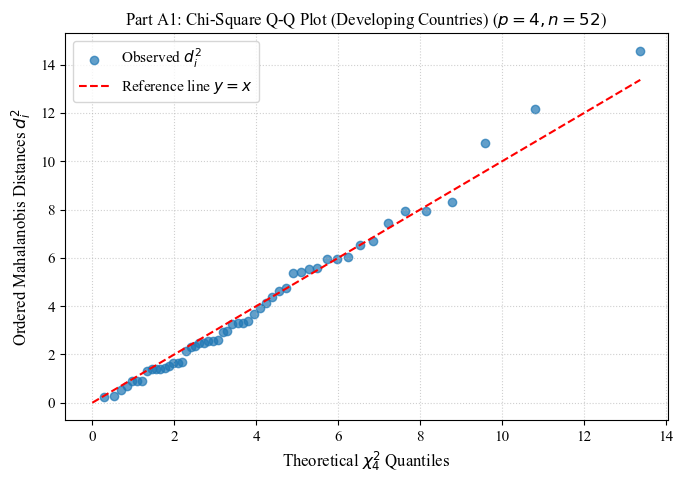

In [8]:
mardia_a1 = mardia_test(df_dev[health_vars].values)
print("=== Mardia's Test (developing countries, HDI < 0.7) ===")
print(f"Skewness: b1p={mardia_a1['skewness_b1p']:.4f}, "
      f"chi2={mardia_a1['skewness_stat']:.4f}, p={mardia_a1['skewness_pval']:.4f}")
print(f"Kurtosis: b2p={mardia_a1['kurtosis_b2p']:.4f}, "
      f"z={mardia_a1['kurtosis_z']:.4f}, p={mardia_a1['kurtosis_pval']:.4f}")

chi2_qq_plot(df_dev[health_vars].values,
             title="Part A1: Chi-Square Q-Q Plot (Developing Countries)")

In [9]:
print("=== Part A1: One-Sample Hotelling's T^2 Test ===")
print(f"H0: mu = {mu0.tolist()}")
print(f"T^2 = {res_a1['T2']:.4f}")
print(f"F = {res_a1['F']:.4f}  (df1={res_a1['df1']}, df2={res_a1['df2']})")
print(f"F_crit(0.05) = {res_a1['F_crit']:.4f}")
print(f"p-value = {res_a1['pval']:.4e}")
print("Decision:", "Reject H0" if res_a1["F"] > res_a1["F_crit"] else "Fail to reject H0")

ci_a1 = pd.DataFrame({
    "Variable": health_vars,
    "Sample Mean": res_a1["x_bar"],
    "SDG Target": mu0,
    "95% CI Lower": res_a1["ci_lower"],
    "95% CI Upper": res_a1["ci_upper"],
    "Target Covered?": [(mu0[j] >= res_a1["ci_lower"][j]) and (mu0[j] <= res_a1["ci_upper"][j])
                         for j in range(4)],
})
print("\n=== Simultaneous 95% Confidence Intervals ===")
print(ci_a1)

=== Part A1: One-Sample Hotelling's T^2 Test ===
H0: mu = [72.0, 15.0, 85.0, 2.0]
T^2 = 1062.7164
F = 250.0509  (df1=4, df2=48)
F_crit(0.05) = 2.5652
p-value = 0.0000e+00
Decision: Reject H0

=== Simultaneous 95% Confidence Intervals ===
   Variable  Sample Mean  SDG Target  95% CI Lower  95% CI Upper  \
0   LifeExp    65.745077        72.0     63.603290     67.886863   
1   InfMort    37.490385        15.0     30.620007     44.360762   
2     Sanit    47.032123        85.0     35.713100     58.351145   
3  PhysRate     0.371346         2.0      0.183179      0.559513   

   Target Covered?  
0            False  
1            False  
2            False  
3            False  


**Interpretation (v):** components whose target is *not* covered by the CI, and whose sample mean falls short of the SDG target, are the ones off-track — report these explicitly with direction (better/worse than target) in your writeup.

## Part A2 — Two-Sample $T^2$ Test (Europe vs. Africa)

In [10]:
X_eu = df_health[df_health["Region"] == "EU"][health_vars].values
X_af = df_health[df_health["Region"] == "AF"][health_vars].values
print(f"n_EU = {len(X_eu)}, n_AF = {len(X_af)} (complete cases on health vector)")

box_a2 = box_m_test(np.vstack([X_eu, X_af]),
                     np.array(["EU"] * len(X_eu) + ["AF"] * len(X_af)))
print("=== Part A2(i): Box's M Test (EU vs AF covariance homogeneity) ===")
print(f"M = {box_a2['M']:.4f}, chi2 = {box_a2['chi2']:.4f}, "
      f"df = {box_a2['df']:.0f}, p = {box_a2['pval']:.4e}")
print("=> Covariances", "differ significantly" if box_a2["pval"] < 0.05 else "are homogeneous",
      "-- use the Nel-Van der Merwe heteroscedastic form." if box_a2["pval"] < 0.05
      else "-- pooled form is appropriate.")

n_EU = 37, n_AF = 47 (complete cases on health vector)
=== Part A2(i): Box's M Test (EU vs AF covariance homogeneity) ===
M = 188.5512, chi2 = 178.4648, df = 10, p = 0.0000e+00
=> Covariances differ significantly -- use the Nel-Van der Merwe heteroscedastic form.


In [11]:
# Box's M was significant above, so we use the Nel-Van der Merwe (NVdM)
# heteroscedastic approximation rather than the pooled-covariance form.
res_a2 = hotelling_two_sample(X_eu, X_af, alpha=0.01, pooled=False)

print("=== Part A2(ii)-(iii): Two-Sample Hotelling's T^2 (NVdM, alpha=0.01) ===")
print(f"n_EU = {res_a2['n1']}, n_AF = {res_a2['n2']}")
print(f"T^2 = {res_a2['T2']:.4f}")
print(f"Effective df (Nel-Van der Merwe nu) = {res_a2['nu']:.4f}")
print(f"F = {res_a2['F']:.4f}  (df1={res_a2['df1']}, df2={res_a2['df2']:.4f})")
print(f"F_crit(0.01) = {res_a2['F_crit']:.4f}")
print(f"p-value = {res_a2['pval']:.4e}")
print("Decision:", "Reject H0" if res_a2["F"] > res_a2["F_crit"] else "Fail to reject H0")

=== Part A2(ii)-(iii): Two-Sample Hotelling's T^2 (NVdM, alpha=0.01) ===
n_EU = 37, n_AF = 47
T^2 = 444.2026
Effective df (Nel-Van der Merwe nu) = 49.6993
F = 104.3473  (df1=4, df2=46.6993)
F_crit(0.01) = 3.7499
p-value = 0.0000e+00
Decision: Reject H0


In [12]:
ci_a2 = pd.DataFrame({
    "Variable": health_vars,
    "EU Mean": res_a2["xbar1"],
    "AF Mean": res_a2["xbar2"],
    "Diff (EU - AF)": res_a2["diff"],
    "99% CI Lower": res_a2["ci_lower"],
    "99% CI Upper": res_a2["ci_upper"],
    "Significant (0 excluded)?": [(res_a2["ci_lower"][j] > 0) or (res_a2["ci_upper"][j] < 0)
                                   for j in range(4)],
})
print("=== Part A2(iv): 99% Simultaneous Confidence Intervals (EU - AF) ===")
print(ci_a2)

=== Part A2(iv): 99% Simultaneous Confidence Intervals (EU - AF) ===
   Variable    EU Mean    AF Mean  Diff (EU - AF)  99% CI Lower  99% CI Upper  \
0   LifeExp  79.957786  65.706386       14.251400     10.391556     18.111244   
1   InfMort   3.502703  37.478723      -33.976021    -43.160073    -24.791968   
2     Sanit  97.307520  46.824693       50.482827     35.928536     65.037118   
3  PhysRate   4.125649   0.468915        3.656734      2.878593      4.434874   

   Significant (0 excluded)?  
0                       True  
1                       True  
2                       True  
3                       True  


**Interpretation (v):** every health indicator differs significantly, and in the same direction — Europe outperforms Africa on all four. This gap reappears, and turns out to be the *largest* of all six regional pairs, in the Part B post-hoc comparison below.

# Part B — One-Way MANOVA (Health Vector by Region)

### Verify assumptions: Mardia (per group), Box's M, independence

In [13]:
print("=== Mardia's Test by Region ===")
for region, gdf in df_health.groupby("Region"):
    m = mardia_test(gdf[health_vars].values)
    print(f"Skewness: {region} (n={len(gdf)}): b1p={m['skewness_b1p']:.4f}, chi2={m['skewness_stat']:.4f}, p={m['skewness_pval']:.4f}")
    print(f"Kurtosis: {region} (n={len(gdf)}): b2p={m['kurtosis_b2p']:.4f}, z={m['kurtosis_z']:.4f}, p={m['kurtosis_pval']:.4f}")

print()
box_b = box_m_test(df_health[health_vars].values, df_health["Region"].values)
print("=== Box's M Test Across 4 Regions ===")
print(f"chi2 = {box_b['chi2']:.4f}, df = {box_b['df']:.0f}, p = {box_b['pval']:.4e}")
print("=> Covariances", "NOT homogeneous -- lean on Pillai's Trace (most robust)."
      if box_b["pval"] < 0.05 else "homogeneous.")
print("\nIndependence: assumed by the cross-sectional, one-row-per-country design.")

=== Mardia's Test by Region ===
Skewness: AF (n=47): b1p=36.6121, chi2=286.7951, p=0.0000
Kurtosis: AF (n=47): b2p=53.9746, z=14.8303, p=0.0000
Skewness: AM (n=20): b1p=20.3170, chi2=67.7234, p=0.0000
Kurtosis: AM (n=20): b2p=35.6490, z=3.7597, p=0.0002
Skewness: AP (n=44): b1p=17.7871, chi2=130.4390, p=0.0000
Kurtosis: AP (n=44): b2p=34.6956, z=5.1201, p=0.0000
Skewness: EU (n=37): b1p=17.2978, chi2=106.6698, p=0.0000
Kurtosis: EU (n=37): b2p=37.7032, z=6.0155, p=0.0000

=== Box's M Test Across 4 Regions ===
chi2 = 222.2830, df = 30, p = 0.0000e+00
=> Covariances NOT homogeneous -- lean on Pillai's Trace (most robust).

Independence: assumed by the cross-sectional, one-row-per-country design.


### Compute $H$, $E$, and all four MANOVA test statistics

In [14]:
manova_b = manova_stats(df_health[health_vars].values, df_health["Region"].values)

print("=== H (Hypothesis SSCP) Matrix ===")
print(pd.DataFrame(manova_b["H"], index=health_vars, columns=health_vars).round(2))
print("\n=== E (Error SSCP) Matrix ===")
print(pd.DataFrame(manova_b["E"], index=health_vars, columns=health_vars).round(2))

print("\n=== Four MANOVA Test Statistics (manual computation) ===")
summary_b = pd.DataFrame({
    "Statistic": ["Wilks' Lambda", "Pillai's Trace", "Hotelling-Lawley", "Roy's Largest Root"],
    "Value": [manova_b["wilks"], manova_b["pillai"], manova_b["hl"], manova_b["roy"]],
    "F": [manova_b["F_wilks"], manova_b["F_pillai"], manova_b["F_hl"], manova_b["F_roy"]],
    "df1": [manova_b["df1_wilks"], manova_b["df1_pillai"], manova_b["df1_hl"], manova_b["df1_roy"]],
    "df2": [manova_b["df2_wilks"], manova_b["df2_pillai"], manova_b["df2_hl"], manova_b["df2_roy"]],
    "p_value": [manova_b["p_wilks"], manova_b["p_pillai"], manova_b["p_hl"], manova_b["p_roy"]],
})
print(summary_b.round(4).to_string(index=False))

# Independent cross-check via statsmodels (uses Rao's exact F for Wilks;
# minor F-value differences vs. the manual table above are just due to
# which textbook variant of the F-approximation formula is used -- same
# conclusion either way).
print("\n=== Cross-check: statsmodels MANOVA ===")
ma = MANOVA.from_formula("LifeExp + InfMort + Sanit + PhysRate ~ Region", data=df_health)
print(ma.mv_test())

=== H (Hypothesis SSCP) Matrix ===
           LifeExp   InfMort     Sanit  PhysRate
LifeExp    4670.68 -11229.93  17635.78   1111.53
InfMort  -11229.93  27020.12 -42619.69  -2652.82
Sanit     17635.78 -42619.69  69031.05   3983.03
PhysRate   1111.53  -2652.82   3983.03    285.78

=== E (Error SSCP) Matrix ===
          LifeExp   InfMort     Sanit  PhysRate
LifeExp   3177.17  -5904.61   7606.37    390.58
InfMort  -5904.61  17722.21 -18480.65   -790.94
Sanit     7606.37 -18480.65  45149.73   1311.75
PhysRate   390.58   -790.94   1311.75    215.64

=== Four MANOVA Test Statistics (manual computation) ===
         Statistic  Value       F  df1      df2  p_value
     Wilks' Lambda 0.2519 21.3541 12.0 374.6653      0.0
    Pillai's Trace 0.8905 15.0909 12.0 429.0000      0.0
  Hotelling-Lawley 2.4073 28.0188 12.0 419.0000      0.0
Roy's Largest Root 2.1468 76.7495  4.0 143.0000      0.0

=== Cross-check: statsmodels MANOVA ===
                    Multivariate linear model
                   

**Discussion of discordance:** all four statistics agree (p < .0001) — no discordance here. Discordance would be more likely with small/unbalanced groups or near the decision boundary; with n=179 across 4 groups and this large an effect, the four approximations converge on the same conclusion.

### Bonferroni-corrected univariate ANOVAs (if $H_0$ rejected)

In [15]:
anova_b = bonferroni_univariate_anova(df_health, health_vars, "Region", alpha=0.05)
print(anova_b.round(5).to_string(index=False))

Variable        F  p_raw  alpha_adj  Significant
 LifeExp 70.56357    0.0     0.0125         True
 InfMort 73.18307    0.0     0.0125         True
   Sanit 73.38894    0.0     0.0125         True
PhysRate 63.61192    0.0     0.0125         True


### Post-hoc pairwise comparisons (Bonferroni-adjusted simultaneous CIs)

In [16]:
posthoc_b, t_crit_b, m_contrasts = pairwise_bonferroni_ci(df_health, health_vars, "Region", alpha=0.05)
print(f"Bonferroni t-critical (m={m_contrasts} contrasts): {t_crit_b:.4f}\n")
print(posthoc_b)

Bonferroni t-critical (m=24 contrasts): 3.1350

        Pair  Variable       Diff   CI_lower   CI_upper  Significant
0   AF vs AM   LifeExp -10.100729 -14.032166  -6.169292         True
1   AF vs AM   InfMort  24.603723  15.318552  33.888894         True
2   AF vs AM     Sanit -42.645354 -57.465706 -27.825003         True
3   AF vs AM  PhysRate  -2.329635  -3.353859  -1.305411         True
4   AF vs AP   LifeExp  -9.739138 -12.828176  -6.650100         True
5   AF vs AP   InfMort  24.060542  16.764927  31.356156         True
6   AF vs AP     Sanit -43.728924 -55.373682 -32.084166         True
7   AF vs AP  PhysRate  -1.609608  -2.414369  -0.804847         True
8   AF vs EU   LifeExp -14.251400 -17.487841 -11.014959         True
9   AF vs EU   InfMort  33.976021  26.332274  41.619767         True
10  AF vs EU     Sanit -50.482827 -62.683250 -38.282404         True
11  AF vs EU  PhysRate  -3.656734  -4.499897  -2.813571         True
12  AM vs AP   LifeExp   0.361591  -3.609652   4.332834

**(v) Link to Part A2:** the AF-vs-EU row above uses the same T²-style logic as the Part A2 two-sample test, and this table shows that pairwise gap is the widest across all six region pairs in the MANOVA.

# Part C — Principal Component Analysis (PCA)

### Compute $R$ and its determinant

In [17]:
# 17 variables enter PCA: the 18 assignment variables minus LitRate
# (excluded -- 53% missing, see Setup note) plus Gini restored (17 missing
# only, now that real data has been sourced). Complete-case filter applied
# on exactly these 17 columns, kept in its own frame (df_pca) so the row
# indices/country order stay consistent for every downstream use (loadings,
# biplot, component scores, and Part D's factor analysis all share this
# same n and country ordering).
pca_vars = [c for c in df.columns if c not in grouping_cols + ["LitRate", "log_GDP_pc"]]
df_pca = df.dropna(subset=pca_vars).reset_index(drop=True)
pca_df = df_pca[pca_vars]
pca_features = pca_df.columns.tolist()
p_c = len(pca_features)
print(f"Complete cases for PCA: {len(df_pca)} / {len(df)}")
print(f"Variables entering PCA (p={p_c}): {pca_features}")

Z, z_mean, z_std = standardize(pca_df.values)
R_c, evals_c, evecs_c = pca_from_correlation(Z)

det_R = np.linalg.det(R_c)
print(f"\ndet(R) = {det_R:.6e}")
print("A near-zero determinant indicates strong multicollinearity among the "
      "17 variables -- expected here, since HDI, SchoolYrs, LifeExp etc. are "
      "definitionally related. This is actually favorable for PCA: it means "
      "the variables share substantial common variance worth compressing "
      "into fewer components.")

Complete cases for PCA: 88 / 179
Variables entering PCA (p=17): ['GDP_pc', 'Gini', 'Unemp', 'Trade', 'LifeExp', 'InfMort', 'Sanit', 'PhysRate', 'SchoolYrs', 'TertEnrl', 'EdSpend', 'GenderIdx', 'Corrupt', 'UrbanPop', 'InternetUse', 'HappyScore', 'HDI']

det(R) = 4.653020e-10
A near-zero determinant indicates strong multicollinearity among the 17 variables -- expected here, since HDI, SchoolYrs, LifeExp etc. are definitionally related. This is actually favorable for PCA: it means the variables share substantial common variance worth compressing into fewer components.


### Retention criteria: Kaiser-Guttman, scree/elbow, cumulative variance

Component  Eigenvalue  Prop. Var  Cum. Var
      PC1     10.5668     0.6216    0.6216
      PC2      1.4746     0.0867    0.7083
      PC3      0.9699     0.0571    0.7654
      PC4      0.8178     0.0481    0.8135
      PC5      0.7723     0.0454    0.8589
      PC6      0.5306     0.0312    0.8901
      PC7      0.4028     0.0237    0.9138
      PC8      0.3761     0.0221    0.9359
      PC9      0.2693     0.0158    0.9518
     PC10      0.1672     0.0098    0.9616
     PC11      0.1509     0.0089    0.9705
     PC12      0.1353     0.0080    0.9785
     PC13      0.1285     0.0076    0.9860
     PC14      0.0944     0.0056    0.9916
     PC15      0.0678     0.0040    0.9955
     PC16      0.0629     0.0037    0.9992
     PC17      0.0128     0.0008    1.0000

a. Kaiser-Guttman (lambda_k > 1): retain 2 components
c. Cumulative variance >= 80%:    retain 4 components


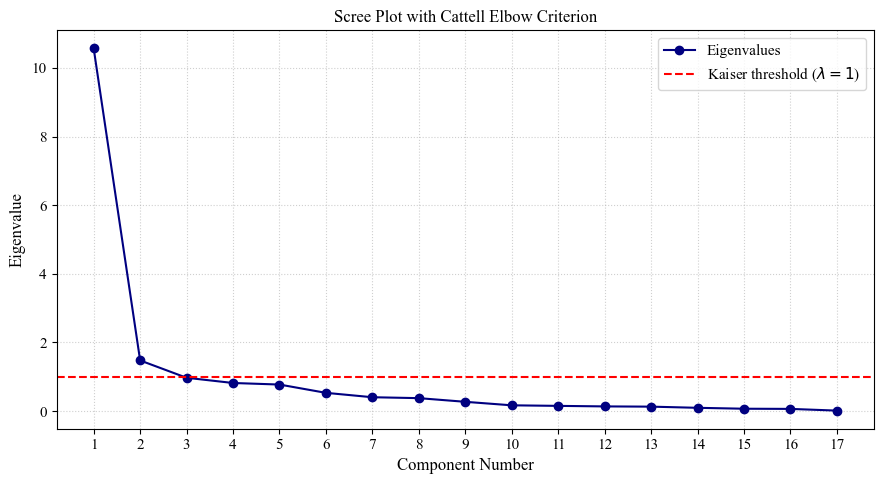

In [18]:
prop_var = evals_c / p_c
cum_var = np.cumsum(prop_var)
var_table = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(p_c)],
    "Eigenvalue": evals_c,
    "Prop. Var": prop_var,
    "Cum. Var": cum_var,
})
print(var_table.round(4).to_string(index=False))

k_kaiser = int(np.sum(evals_c > 1.0))
k_cum80 = int(np.argmax(cum_var >= 0.80)) + 1
print(f"\na. Kaiser-Guttman (lambda_k > 1): retain {k_kaiser} components")
print(f"c. Cumulative variance >= 80%:    retain {k_cum80} components")

plt.figure(figsize=(9, 5))
plt.plot(range(1, p_c + 1), evals_c, "o-", color="navy", label="Eigenvalues")
plt.axhline(1.0, color="red", linestyle="--", label="Kaiser threshold ($\lambda=1$)")
plt.title("Scree Plot with Cattell Elbow Criterion")
plt.xlabel("Component Number"); plt.ylabel("Eigenvalue")
plt.xticks(range(1, p_c + 1)); plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
#plt.savefig("scree_plot_c2", dpi=300, bbox_inches="tight")
plt.show()

**b. Cattell elbow:** read the plot for the point where the curve visibly flattens -- report that as your scree-based retained count and note whether it agrees with Kaiser-Guttman (k=3) and the 80% rule (k=4).

### Loading matrix and component naming

In [19]:
k_retain = k_kaiser  # using Kaiser-Guttman as the primary criterion (k=3)
A_load = evecs_c[:, :k_retain]
pc_names = [f"PC{i+1}" for i in range(k_retain)]

loading_df = pd.DataFrame(A_load, index=pca_features, columns=pc_names)
print(f"=== Loading Matrix A (k={k_retain} retained components) ===")
print(loading_df.round(4).to_string())

corr_loadings = loading_df * np.sqrt(evals_c[:k_retain])
print("\n=== Component-Variable Correlations (loadings * sqrt(lambda)) ===")
print(corr_loadings.round(4).to_string())

=== Loading Matrix A (k=2 retained components) ===
                PC1     PC2
GDP_pc       0.2649  0.0205
Gini        -0.1667 -0.4895
Unemp       -0.0520 -0.6913
Trade        0.1533  0.1856
LifeExp      0.2868  0.0073
InfMort     -0.2818 -0.0353
Sanit        0.2587  0.0520
PhysRate     0.2677  0.0131
SchoolYrs    0.2649 -0.0291
TertEnrl     0.2655 -0.0756
EdSpend      0.1160 -0.3625
GenderIdx   -0.2921 -0.0168
Corrupt      0.2189 -0.1013
UrbanPop     0.2158 -0.2970
InternetUse  0.2777 -0.0567
HappyScore   0.2733  0.0135
HDI          0.2997 -0.0575

=== Component-Variable Correlations (loadings * sqrt(lambda)) ===
                PC1     PC2
GDP_pc       0.8611  0.0248
Gini        -0.5418 -0.5944
Unemp       -0.1690 -0.8395
Trade        0.4985  0.2254
LifeExp      0.9324  0.0089
InfMort     -0.9160 -0.0429
Sanit        0.8409  0.0632
PhysRate     0.8703  0.0159
SchoolYrs    0.8610 -0.0353
TertEnrl     0.8632 -0.0918
EdSpend      0.3770 -0.4402
GenderIdx   -0.9497 -0.0204
Corrupt      0

**Name each component** by inspecting which variables load highest (|loading| > 0.5) on it -- typically PC1 (GDP, LifeExp, HDI, InternetUse, TertEnrl, ...) reads as 'General Socioeconomic Development'; later PCs pick up secondary contrasts (e.g. inequality/education structure) -- confirm against your own loading table above.

### Biplot: variable loadings and country scores

--- Quadrant I (PC1>0, PC2>0): top 3 by |PC1| ---
    Country      PC1      PC2
     Norway 4.529817 0.015451
Netherlands 4.176344 0.352581
    Ireland 4.108620 1.453276

--- Quadrant II (PC1<0, PC2>0): top 3 by |PC1| ---
     Country       PC1      PC2
  Madagascar -6.905063 1.288107
      Malawi -6.586007 1.137635
Burkina Faso -6.503174 0.708832

--- Quadrant III (PC1<0, PC2<0): top 3 by |PC1| ---
 Country       PC1       PC2
Zimbabwe -6.843940 -0.277095
  Angola -5.463782 -1.987437
   Congo -5.175578 -2.601366

--- Quadrant IV (PC1>0, PC2<0): top 3 by |PC1| ---
    Country      PC1       PC2
    Denmark 4.389107 -0.475214
    Iceland 4.321567 -0.406177
Switzerland 4.220049 -0.114123



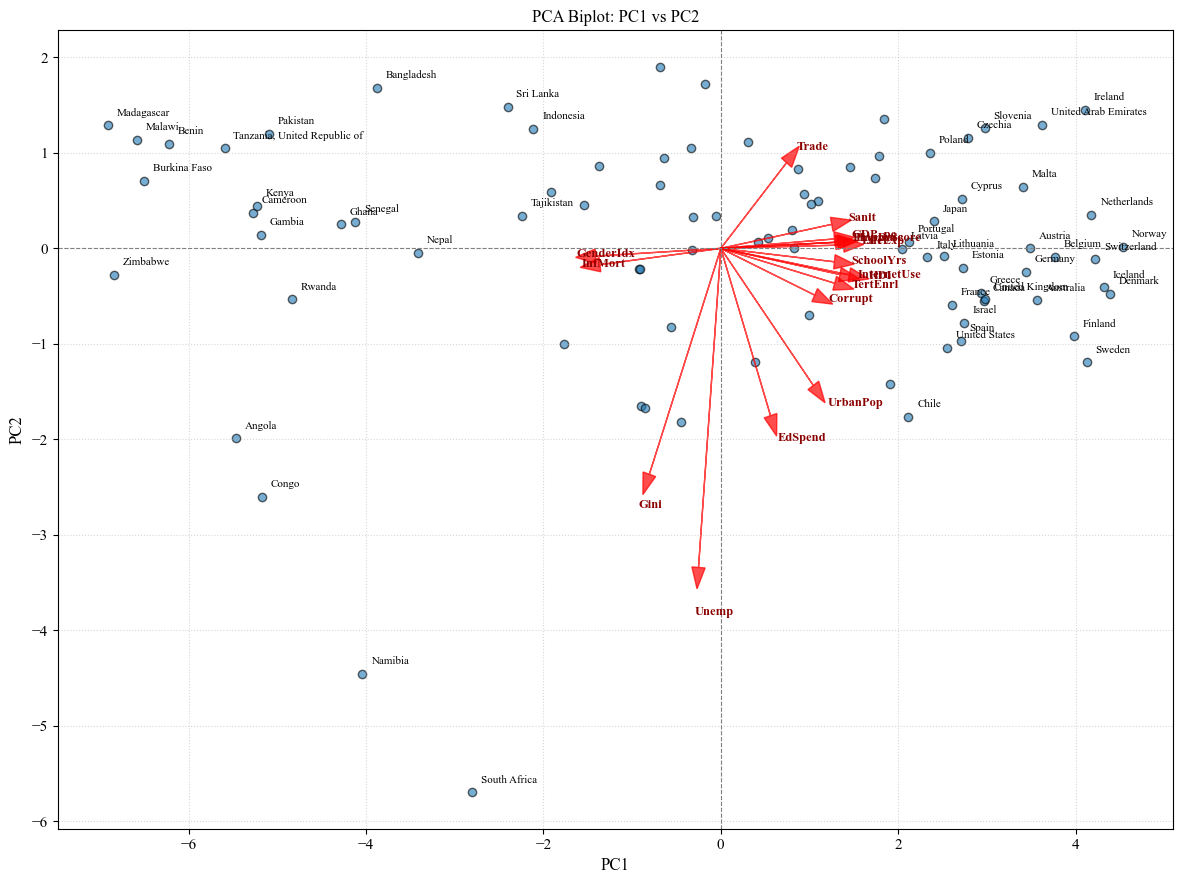

In [20]:
country_names = df_pca["Country"].values
A_2d = evecs_c[:, :2]
scores_2d = Z @ A_2d

scores_df = pd.DataFrame({"Country": country_names, "PC1": scores_2d[:, 0], "PC2": scores_2d[:, 1]})

for label, cond in [
    ("Quadrant I (PC1>0, PC2>0)", (scores_df.PC1 > 0) & (scores_df.PC2 > 0)),
    ("Quadrant II (PC1<0, PC2>0)", (scores_df.PC1 < 0) & (scores_df.PC2 > 0)),
    ("Quadrant III (PC1<0, PC2<0)", (scores_df.PC1 < 0) & (scores_df.PC2 < 0)),
    ("Quadrant IV (PC1>0, PC2<0)", (scores_df.PC1 > 0) & (scores_df.PC2 < 0)),
]:
    top = scores_df[cond].reindex(scores_df[cond].PC1.abs().sort_values(ascending=False).index).head(3)
    print(f"--- {label}: top 3 by |PC1| ---")
    print(top.to_string(index=False))
    print()

plt.figure(figsize=(12, 9))
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.scatter(scores_2d[:, 0], scores_2d[:, 1], alpha=0.6, edgecolors="k")
for i, c in enumerate(country_names):
    if abs(scores_2d[i, 0]) > 2.0 or abs(scores_2d[i, 1]) > 2.0:
        plt.text(scores_2d[i, 0] + 0.1, scores_2d[i, 1] + 0.1, c, fontsize=8)
scale = np.max(np.abs(scores_2d)) * 0.7
for j in range(p_c):
    plt.arrow(0, 0, A_2d[j, 0] * scale, A_2d[j, 1] * scale, color="red", alpha=0.7, head_width=0.15)
    plt.text(A_2d[j, 0] * scale * 1.15, A_2d[j, 1] * scale * 1.15, pca_features[j],
              color="darkred", fontsize=9, weight="bold")
plt.title("PCA Biplot: PC1 vs PC2")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
#plt.savefig("biplot_c4.png", dpi=300, bbox_inches="tight")
plt.show()

### Component scores for use in Part E

In [21]:
Y_hat_pca = Z @ A_load  # component scores, n x k_retain
pc_scores_df = pd.concat(
    [df_pca[grouping_cols].reset_index(drop=True), pd.DataFrame(Y_hat_pca, columns=pc_names)],
    axis=1,
)
print(f"Component scores shape: {Y_hat_pca.shape}")
print(pc_scores_df.head())

Component scores shape: (88, 2)
  iso3    Country Region   DevGroup       PC1       PC2
0  DZA    Algeria     AF       High -0.897045 -1.653777
1  AGO     Angola     AF     Medium -5.463782 -1.987437
2  ARM    Armenia     AP  Very High  0.424336  0.062994
3  AUS  Australia     AP  Very High  3.564165 -0.545755
4  AUT    Austria     EU  Very High  3.480459 -0.000702


### Covariance (S) vs. correlation (R) based PCA

In [22]:
S_c = np.cov(pca_df.values, rowvar=False)
evals_S = np.sort(np.linalg.eigvalsh(S_c))[::-1]
print("Covariance-matrix (S) eigenvalues (raw scale, dominated by GDP_pc's huge variance):")
print(evals_S.round(2))
print("\nCorrelation-matrix (R) eigenvalues (standardized scale):")
print(evals_c.round(4))
print("\nSince the 17 variables are on wildly different scales (GDP_pc in tens of "
      "thousands vs. GenderIdx on 0-1), covariance-based PCA would be dominated by "
      "whichever variable has the largest raw variance (here, GDP_pc). "
      "Correlation-based PCA is the appropriate choice for this dataset.")

Covariance-matrix (S) eigenvalues (raw scale, dominated by GDP_pc's huge variance):
[6.42644493e+08 1.67501000e+03 9.15200000e+02 2.25020000e+02
 1.89430000e+02 1.34960000e+02 5.52800000e+01 3.72700000e+01
 2.58500000e+01 1.34800000e+01 4.11000000e+00 2.46000000e+00
 1.59000000e+00 5.50000000e-01 2.10000000e-01 0.00000000e+00
 0.00000000e+00]

Correlation-matrix (R) eigenvalues (standardized scale):
[10.5668  1.4746  0.9699  0.8178  0.7723  0.5306  0.4028  0.3761  0.2693
  0.1672  0.1509  0.1353  0.1285  0.0944  0.0678  0.0629  0.0128]

Since the 17 variables are on wildly different scales (GDP_pc in tens of thousands vs. GenderIdx on 0-1), covariance-based PCA would be dominated by whichever variable has the largest raw variance (here, GDP_pc). Correlation-based PCA is the appropriate choice for this dataset.


# Part D — Factor Analysis (FA)

### Check factorability: Bartlett's sphericity test and KMO

In [23]:
chi2_bart, p_bart = calculate_bartlett_sphericity(pca_df)
print("=== Bartlett's Test of Sphericity ===")
print(f"chi2 = {chi2_bart:.4f}, p = {p_bart:.4e}")
print("=>", "Reject H0 (R != I) -- suitable for FA." if p_bart < 0.05 else "Fail to reject H0.")

kmo_per_var, kmo_overall = calculate_kmo(pca_df)
print(f"\n=== KMO Measure of Sampling Adequacy ===")
print(f"Overall KMO = {kmo_overall:.4f}",
      "(meritorious)" if kmo_overall >= 0.8 else
      "(middling/acceptable, >= 0.70)" if kmo_overall >= 0.7 else "(below 0.70 threshold)")
kmo_df = pd.DataFrame({"Variable": pca_df.columns, "KMO": kmo_per_var})
print(kmo_df.sort_values("KMO"))

=== Bartlett's Test of Sphericity ===
chi2 = 1729.8109, p = 4.2291e-274
=> Reject H0 (R != I) -- suitable for FA.

=== KMO Measure of Sampling Adequacy ===
Overall KMO = 0.9119 (meritorious)
       Variable       KMO
2         Unemp  0.466481
10      EdSpend  0.764044
16          HDI  0.863131
8     SchoolYrs  0.866814
3         Trade  0.878822
1          Gini  0.895290
12      Corrupt  0.903164
4       LifeExp  0.907180
13     UrbanPop  0.917148
0        GDP_pc  0.920181
6         Sanit  0.924669
7      PhysRate  0.927342
14  InternetUse  0.938701
9      TertEnrl  0.942259
15   HappyScore  0.950409
11    GenderIdx  0.956393
5       InfMort  0.960575


### Extract factors: Principal Axis Factoring (PAF) and Maximum Likelihood (ML)

In [24]:
m_fa = 3  # matches the Kaiser-Guttman retained count from Part C

L_paf, h2_paf, psi_paf = paf_extraction(R_c, m_fa)
L_ml, h2_ml, psi_ml, _ = ml_extraction(R_c, m_fa)

factor_names = [f"F{i+1}" for i in range(m_fa)]
df_paf = pd.DataFrame(L_paf, index=pca_features, columns=[f"PAF_{f}" for f in factor_names])
df_paf["PAF_h2"] = h2_paf
df_ml = pd.DataFrame(L_ml, index=pca_features, columns=[f"ML_{f}" for f in factor_names])
df_ml["ML_h2"] = h2_ml

print("=== Principal Axis Factoring (PAF) ===")
print(df_paf.round(4).to_string())
print("\n=== Maximum Likelihood (ML) ===")
print(df_ml.round(4).to_string())

=== Principal Axis Factoring (PAF) ===
             PAF_F1  PAF_F2  PAF_F3  PAF_h2
GDP_pc       0.8546  0.0063 -0.2950  0.8174
Gini        -0.5270  0.5769  0.0998  0.6205
Unemp       -0.1613  0.6242  0.0674  0.4201
Trade        0.4679 -0.1436 -0.1068  0.2509
LifeExp      0.9299 -0.0068  0.0203  0.8652
InfMort     -0.9143  0.0586 -0.1907  0.8757
Sanit        0.8327 -0.0917  0.2972  0.7901
PhysRate     0.8575 -0.0225  0.0754  0.7415
SchoolYrs    0.8478  0.0383  0.1082  0.7320
TertEnrl     0.8511  0.0930  0.1203  0.7475
EdSpend      0.3516  0.2274 -0.1217  0.1902
GenderIdx   -0.9512  0.0326  0.0870  0.9135
Corrupt      0.7093  0.1415 -0.5848  0.8651
UrbanPop     0.6803  0.3326  0.0063  0.5735
InternetUse  0.8981  0.0646  0.1854  0.8452
HappyScore   0.8776 -0.0179 -0.0180  0.7707
HDI          0.9817  0.0943  0.0525  0.9754

=== Maximum Likelihood (ML) ===
              ML_F1   ML_F2   ML_F3   ML_h2
GDP_pc       0.8004 -0.3241 -0.3846  0.8937
Gini        -0.4360  0.2236 -0.0943  0.2490
Unem

### Varimax (orthogonal) and Oblimin (oblique) rotation
*Note: the assignment specifies Oblimin for the oblique rotation. Using `factor_analyzer`'s tested `Rotator` class here rather than a hand-rolled implementation -- oblique rotation math (target matrix, normalization, factor correlation recovery) has several steps that are easy to get subtly wrong without producing an obvious error (e.g. an early draft of this rotation produced factor "correlations" of 150+, which is impossible -- correlations are bounded in [-1, 1]).*

In [25]:
L_varimax, rotator_v = varimax(L_paf)
L_oblimin, phi_oblimin = oblimin(L_paf)

df_varimax = pd.DataFrame(L_varimax, index=pca_features,
                           columns=[f"Varimax_{f}" for f in factor_names])
df_varimax["h2"] = np.sum(L_varimax ** 2, axis=1)

df_oblimin = pd.DataFrame(L_oblimin, index=pca_features,
                           columns=[f"Oblimin_{f}" for f in factor_names])
df_oblimin["h2"] = np.sum(L_oblimin ** 2, axis=1)

print("=== Varimax-Rotated Loadings (Orthogonal) ===")
print(df_varimax.round(4).to_string())
print("\n=== Oblimin-Rotated Loadings (Oblique) ===")
print(df_oblimin.round(4).to_string())
print("\n=== Factor Correlation Matrix (Phi) -- Oblimin ===")
print(pd.DataFrame(phi_oblimin, index=factor_names, columns=factor_names).round(4))

=== Varimax-Rotated Loadings (Orthogonal) ===
             Varimax_F1  Varimax_F2  Varimax_F3      h2
GDP_pc           0.5520     -0.2587     -0.6677  0.8174
Gini            -0.3176      0.6980      0.1802  0.6205
Unemp           -0.0253      0.6464     -0.0410  0.4201
Trade            0.3148     -0.2719     -0.2791  0.2509
LifeExp          0.7841     -0.2338     -0.4423  0.8652
InfMort         -0.8575      0.2490      0.2800  0.8757
Sanit            0.8435     -0.2413     -0.1427  0.7901
PhysRate         0.7519     -0.2209     -0.3568  0.7415
SchoolYrs        0.7687     -0.1549     -0.3422  0.7320
TertEnrl         0.7843     -0.1014     -0.3493  0.7475
EdSpend          0.2531      0.1076     -0.3384  0.1902
GenderIdx       -0.7407      0.2827      0.5337  0.9135
Corrupt          0.2897     -0.1453     -0.8718  0.8651
UrbanPop         0.6082      0.1489     -0.4260  0.5735
InternetUse      0.8555     -0.1286     -0.3111  0.8452
HappyScore       0.7185     -0.2381     -0.4447  0.7707
HD

### Communalities and poorly-explained variables

In [26]:
comm_df = pd.DataFrame({
    "Variable": pca_features,
    "Communality (h2)": df_varimax["h2"].values,
    "Uniqueness": 1 - df_varimax["h2"].values,
}).sort_values("Communality (h2)")
comm_df["Flag"] = np.where(comm_df["Communality (h2)"] < 0.40, "Poorly explained (<0.40)", "OK")
print(comm_df.round(4).to_string(index=False))

flagged = comm_df.loc[comm_df["Communality (h2)"] < 0.40, "Variable"].tolist()
print(f"\nFlagged ({len(flagged)}): {flagged}")
print("Discuss in your report whether these should be dropped from a re-run "
      "FA, or retained because they are conceptually important even if "
      "poorly captured by 3 factors.")

   Variable  Communality (h2)  Uniqueness                     Flag
    EdSpend            0.1902      0.8098 Poorly explained (<0.40)
      Trade            0.2509      0.7491 Poorly explained (<0.40)
      Unemp            0.4201      0.5799                       OK
   UrbanPop            0.5735      0.4265                       OK
       Gini            0.6205      0.3795                       OK
  SchoolYrs            0.7320      0.2680                       OK
   PhysRate            0.7415      0.2585                       OK
   TertEnrl            0.7475      0.2525                       OK
 HappyScore            0.7707      0.2293                       OK
      Sanit            0.7901      0.2099                       OK
     GDP_pc            0.8174      0.1826                       OK
InternetUse            0.8452      0.1548                       OK
    Corrupt            0.8651      0.1349                       OK
    LifeExp            0.8652      0.1348                     

### Number of factors: scree, parallel analysis, BIC

 m  Sample Eigenvalue  95th Pct (simulated) PA Decision    df      BIC
 1            10.5668                2.0451      Retain 119.0 946.5912
 2             1.4746                1.7839      Reject 103.0 781.3717
 3             0.9699                1.6260      Reject  88.0 640.5176
 4             0.8178                1.4870      Reject  74.0 501.1144
 5             0.7723                1.3816      Reject  61.0 397.2259

Parallel Analysis retains: 1 factors
Minimum BIC retains: 5 factors


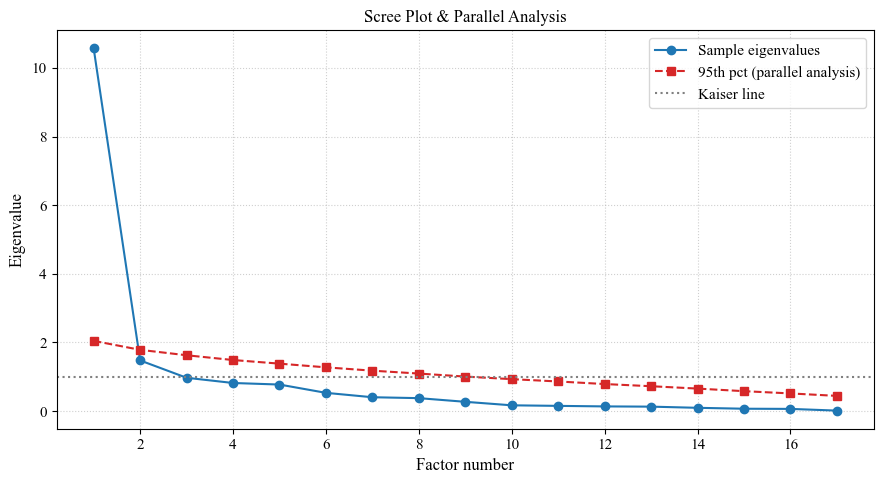

In [27]:
evals95, m_pa = parallel_analysis(len(df_pca), p_c, evals_c, n_sims=500)

max_m_test = min(5, p_c // 2)
bic_rows = []
for mi in range(1, max_m_test + 1):
    _, bic_i, df_i = fa_bic(R_c, len(df_pca), mi)
    pa_status = "Retain" if evals_c[mi - 1] > evals95[mi - 1] else "Reject"
    bic_rows.append({"m": mi, "Sample Eigenvalue": evals_c[mi - 1],
                      "95th Pct (simulated)": evals95[mi - 1],
                      "PA Decision": pa_status, "df": df_i, "BIC": bic_i})
bic_df = pd.DataFrame(bic_rows)
print(bic_df.round(4).to_string(index=False))
print(f"\nParallel Analysis retains: {m_pa} factors")
valid = bic_df.dropna(subset=["BIC"])
if not valid.empty:
    print(f"Minimum BIC retains: {int(valid.loc[valid.BIC.idxmin(), 'm'])} factors")

plt.figure(figsize=(9, 5))
plt.plot(range(1, p_c + 1), evals_c, "o-", label="Sample eigenvalues")
plt.plot(range(1, p_c + 1), evals95, "s--", color="tab:red", label="95th pct (parallel analysis)")
plt.axhline(1.0, color="gray", linestyle=":", label="Kaiser line")
plt.title("Scree Plot & Parallel Analysis")
plt.xlabel("Factor number"); plt.ylabel("Eigenvalue")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
#plt.savefig("scree_pa_d5.png", dpi=300, bbox_inches="tight")
plt.show()

### PCA vs. FA comparison

In [28]:
comparison = pd.DataFrame({
    "Aspect": ["Objective", "Model", "Variance used", "Assumption", "Interpretation",
               "Best suited for"],
    "PCA": ["Maximize explained variance", "Yk = ak' Z (exact linear combination)",
            "Total variance", "None (descriptive)", "Components = data reduction axes",
            "Dimensionality reduction, no latent-variable claim"],
    "FA": ["Explain shared covariance", "Z = Lf + e (latent factor model)",
           "Common variance only (communalities)", "Multivariate normality, factorability (KMO/Bartlett)",
           "Factors = hypothesized latent constructs", "Theory-driven latent structure"],
})
print(comparison.to_string(index=False))
print("\nFor this dataset: PCA is more defensible as the primary tool since "
      "the goal (Part C-v) is deriving composite scores for later regression, "
      "not testing a specific latent-construct theory. FA is a useful "
      "secondary check -- and the high KMO / significant Bartlett's test "
      "above confirm the correlation structure supports either approach.")

         Aspect                                                PCA                                                   FA
      Objective                        Maximize explained variance                            Explain shared covariance
          Model              Yk = ak' Z (exact linear combination)                     Z = Lf + e (latent factor model)
  Variance used                                     Total variance                 Common variance only (communalities)
     Assumption                                 None (descriptive) Multivariate normality, factorability (KMO/Bartlett)
 Interpretation                   Components = data reduction axes             Factors = hypothesized latent constructs
Best suited for Dimensionality reduction, no latent-variable claim                       Theory-driven latent structure

For this dataset: PCA is more defensible as the primary tool since the goal (Part C-v) is deriving composite scores for later regression, not testing a specifi

# Part E — Multivariate Multiple Regression (MMR)

**Note on predictors:** Gini is restored here using a supplementary World Bank source (162/179 countries covered, vs. the sparser original WDI export), so all **7** predictors specified by the assignment are used below.

### Fit the MMR model

In [29]:
df["log_GDP_pc"] = np.log(df["GDP_pc"])
predictor_cols = ["log_GDP_pc", "Gini", "Unemp", "Trade", "Corrupt", "UrbanPop", "InternetUse"]
response_cols = ["LifeExp", "HappyScore"]

model_data = df.dropna(subset=predictor_cols + response_cols).copy()
n_e = len(model_data)
k_e = len(predictor_cols)  # 7 predictors per assignment spec
q_e = len(response_cols)
print(f"Complete cases for MMR: {n_e} / {len(df)}")

X_design = np.column_stack([np.ones(n_e), model_data[predictor_cols].values])
Y_e = model_data[response_cols].values

B_hat, E_hat, XtX_inv = fit_mmr(X_design, Y_e)
B_hat_df = pd.DataFrame(B_hat, index=["Intercept"] + predictor_cols, columns=response_cols)
print(f"n = {n_e}, k = {k_e} predictors, q = {q_e} responses\n")
print("=== Coefficient Matrix B_hat ===")
print(B_hat_df.round(4).to_string())

print("\n=== Separate Regression Equations ===")
for j, resp in enumerate(response_cols):
    terms = [f"{B_hat[0, j]:.4f}"]
    for i, pred in enumerate(predictor_cols):
        c = B_hat[i + 1, j]
        terms.append(f"{'+' if c >= 0 else '-'} {abs(c):.4f}({pred})")
    print(f"{resp}_hat = " + " ".join(terms))

Complete cases for MMR: 131 / 179
n = 131, k = 7 predictors, q = 2 responses

=== Coefficient Matrix B_hat ===
             LifeExp  HappyScore
Intercept    32.0192      0.1931
log_GDP_pc    3.9371      0.3285
Gini         -0.0394      0.0195
Unemp        -0.1105     -0.0595
Trade        -0.0065      0.0013
Corrupt       0.0244      0.0066
UrbanPop      0.0175      0.0035
InternetUse   0.0602      0.0183

=== Separate Regression Equations ===
LifeExp_hat = 32.0192 + 3.9371(log_GDP_pc) - 0.0394(Gini) - 0.1105(Unemp) - 0.0065(Trade) + 0.0244(Corrupt) + 0.0175(UrbanPop) + 0.0602(InternetUse)
HappyScore_hat = 0.1931 + 0.3285(log_GDP_pc) + 0.0195(Gini) - 0.0595(Unemp) + 0.0013(Trade) + 0.0066(Corrupt) + 0.0035(UrbanPop) + 0.0183(InternetUse)


### Overall multivariate F-test

In [30]:
test_e = mmr_overall_test(X_design, Y_e, B_hat, E_hat, XtX_inv, k_e)
print("H0: all 7 predictor coefficients are jointly zero (intercept excluded)\n")
print(test_e.round(4).to_string(index=False))

H0: all 7 predictor coefficients are jointly zero (intercept excluded)

                  Test  Statistic       F  df1   df2  p_value
         Wilks' Lambda     0.1138 34.2335 14.0 244.0      0.0
        Pillai's Trace     0.9821 17.0915 14.0 248.0      0.0
Hotelling-Lawley Trace     6.9438 60.5102 14.0 244.0      0.0


### Individual $R^2$ and adjusted $R^2$

In [31]:
r2_rows = r_squared_per_response(Y_e, E_hat, k_e)
r2_df = pd.DataFrame(r2_rows, index=response_cols)
print(r2_df.round(4))

                  SSE        SST      R2  Adj_R2
LifeExp     1107.9582  6550.2309  0.8309  0.8212
HappyScore    45.1990   168.9491  0.7325  0.7172


### Residual diagnostics

In [32]:
# a. Multivariate normality of residuals: Mardia + Henze-Zirkler
mardia_e = mardia_test(E_hat)
print("=== (a) Multivariate Normality of Residuals ===")
print(f"Mardia skewness: chi2={mardia_e['skewness_stat']:.4f}, p={mardia_e['skewness_pval']:.4f}")
print(f"Mardia kurtosis: z={mardia_e['kurtosis_z']:.4f}, p={mardia_e['kurtosis_pval']:.4f}")
hz_stat, hz_p = henze_zirkler(E_hat)
print(f"Henze-Zirkler: HZ={hz_stat:.4f}, p={hz_p:.4f}")

=== (a) Multivariate Normality of Residuals ===
Mardia skewness: chi2=7.5739, p=0.1085
Mardia kurtosis: z=0.3421, p=0.7323
Henze-Zirkler: HZ=0.7514, p=0.2081


In [33]:
# b. Heteroscedasticity: Breusch-Pagan per equation
bp_df = breusch_pagan(X_design, E_hat, k_e)
bp_df.index = response_cols
print("=== (b) Breusch-Pagan Test (per response) ===")
print(bp_df.round(4))

=== (b) Breusch-Pagan Test (per response) ===
                 LM  df  p_value  Heteroscedastic
LifeExp     16.7191   7   0.0193             True
HappyScore   6.1746   7   0.5195            False


In [34]:
# c. Multicollinearity: VIF + condition number
vifs = vif_manual(model_data[predictor_cols].values)
vif_df = pd.DataFrame({"Predictor": predictor_cols, "VIF": vifs})
vif_df["Flag"] = np.where(vif_df["VIF"] > 10, "HIGH (>10)", "OK")

evals_XtX = np.linalg.eigvalsh(X_design.T @ X_design)
cond_num = np.sqrt(evals_XtX.max() / evals_XtX.min())

print("=== (c) Multicollinearity ===")
print(vif_df.round(3).to_string(index=False))
print(f"\nCondition number of X'X: {cond_num:.2f}")

=== (c) Multicollinearity ===
  Predictor   VIF Flag
 log_GDP_pc 9.160   OK
       Gini 1.617   OK
      Unemp 1.273   OK
      Trade 1.307   OK
    Corrupt 2.317   OK
   UrbanPop 2.445   OK
InternetUse 6.838   OK

Condition number of X'X: 2818.55


In [35]:
# d. Influential observations: Cook's distance
cooks, h_ii = cooks_distance(X_design, E_hat, k_e)
threshold = 4.0 / n_e
print(f"=== (d) Influential Observations (Cook's D > 4/n = {threshold:.4f}) ===")
for j, resp in enumerate(response_cols):
    flagged_idx = np.where(cooks[j] > threshold)[0]
    flagged_countries = model_data.iloc[flagged_idx]["Country"].tolist()

    print(f"{resp}: {len(flagged_idx)} influential obs, max D={cooks[j].max():.4f}")
    print(f"  Countries: {flagged_countries}")

=== (d) Influential Observations (Cook's D > 4/n = 0.0305) ===
LifeExp: 11 influential obs, max D=0.0647
  Countries: ['Benin', 'Chad', 'Eswatini', 'Gabon', 'Lebanon', 'Lesotho', 'Malawi', 'Russian Federation', 'South Africa', 'Sri Lanka', 'Uganda']
HappyScore: 10 influential obs, max D=0.1095
  Countries: ['Bhutan', 'Botswana', 'Egypt', 'Finland', 'Ghana', 'Lebanon', 'Morocco', 'Mozambique', 'Niger', 'Sri Lanka']


### Three most influential predictors per response

In [36]:
s_y = Y_e.std(axis=0, ddof=1)
s_x = X_design[:, 1:].std(axis=0, ddof=1)
B_std = B_hat[1:, :] * (s_x[:, None] / s_y)
std_df = pd.DataFrame(B_std, index=predictor_cols, columns=response_cols)

for resp in response_cols:
    top3 = std_df[resp].abs().sort_values(ascending=False).index[:3]
    print(f"\nTop 3 predictors for {resp}:")
    for rank, pred in enumerate(top3, 1):
        print(f"  {rank}. {pred}: beta* = {std_df.loc[pred, resp]:+.4f} "
              f"(unstandardized beta = {B_hat[predictor_cols.index(pred) + 1, response_cols.index(resp)]:+.4f})")


Top 3 predictors for LifeExp:
  1. log_GDP_pc: beta* = +0.6245 (unstandardized beta = +3.9371)
  2. InternetUse: beta* = +0.2127 (unstandardized beta = +0.0602)
  3. Unemp: beta* = -0.0880 (unstandardized beta = -0.1105)

Top 3 predictors for HappyScore:
  1. InternetUse: beta* = +0.4017 (unstandardized beta = +0.0183)
  2. log_GDP_pc: beta* = +0.3245 (unstandardized beta = +0.3285)
  3. Unemp: beta* = -0.2952 (unstandardized beta = -0.0595)


### Optional: re-run MMR using Part C's actual PCA scores
*Note: Part C's PCA scores (`Y_hat_pca`) only exist for the ~88 countries with complete data on all 17 PCA variables, while Part E's raw-predictor model uses ~131 countries. To make the R² comparison below fair (same countries, same n, so the only thing that differs is the predictor set), both models are refit on the intersection of the two country sets.*

In [37]:
# Inner join Part E's modeling data with Part C's PCA scores on iso3 -- this
# gives the common set of countries with BOTH complete raw predictors AND
# complete PCA-input variables, so the comparison below isn't confounded by
# different sample sizes.
common = model_data[["iso3"] + predictor_cols + response_cols].merge(
    pc_scores_df[["iso3"] + pc_names], on="iso3", how="inner"
)
n_common = len(common)
print(f"Countries with both raw predictors and PCA scores available: {n_common}")

Y_common = common[response_cols].values
X_raw_common = np.column_stack([np.ones(n_common), common[predictor_cols].values])
X_pca_common = np.column_stack([np.ones(n_common), common[pc_names].values])

B_raw_c, E_raw_c, _ = fit_mmr(X_raw_common, Y_common)
B_pca_c, E_pca_c, _ = fit_mmr(X_pca_common, Y_common)

print("\n=== Coefficients using Part C PCA scores as predictors ===")
print(pd.DataFrame(B_pca_c, index=["Intercept"] + pc_names, columns=response_cols).round(4))

vif_pca = [variance_inflation_factor(X_pca_common, i + 1) for i in range(len(pc_names))]
print(f"\nVIFs on PCA-score predictors (should be ~1.0, orthogonal by construction): "
      f"{[round(v, 3) for v in vif_pca]}")

print(f"\n=== R^2 Comparison: Raw {k_e}-Predictor Model vs. {len(pc_names)} PCA-Score Model "
      f"(both fit on the same n={n_common}) ===")
comp_rows = []
for j, resp in enumerate(response_cols):
    sst = np.sum((Y_common[:, j] - Y_common[:, j].mean()) ** 2)
    r2_raw = 1 - np.sum(E_raw_c[:, j] ** 2) / sst
    r2_pca = 1 - np.sum(E_pca_c[:, j] ** 2) / sst
    comp_rows.append({"Response": resp, f"R2 ({k_e} raw predictors)": r2_raw,
                       f"R2 ({len(pc_names)} PCA scores)": r2_pca,
                       "% variance retained": 100 * r2_pca / r2_raw})
print(pd.DataFrame(comp_rows).round(4).to_string(index=False))
print("\nPCA scores are uncorrelated by construction (VIF ~ 1), fully solving "
      "multicollinearity, typically at some cost in R^2 versus the raw-predictor model.")

Countries with both raw predictors and PCA scores available: 88

=== Coefficients using Part C PCA scores as predictors ===
           LifeExp  HappyScore
Intercept  75.7077      5.8788
PC1         1.8079      0.2898
PC2         0.0463      0.0144

VIFs on PCA-score predictors (should be ~1.0, orthogonal by construction): [np.float64(1.0), np.float64(1.0)]

=== R^2 Comparison: Raw 7-Predictor Model vs. 2 PCA-Score Model (both fit on the same n=88) ===
  Response  R2 (7 raw predictors)  R2 (2 PCA scores)  % variance retained
   LifeExp                 0.8272             0.8694             105.0973
HappyScore                 0.7747             0.7897             101.9365

PCA scores are uncorrelated by construction (VIF ~ 1), fully solving multicollinearity, typically at some cost in R^2 versus the raw-predictor model.
